# Notebook 6: MML Model Fitting — Four Explanatory IRT Models

This notebook fits all four models from Chapter 5 using **Marginal Maximum Likelihood** with Gauss-Hermite quadrature. No external optimization libraries are needed — everything runs with numpy.

**Scripts covered:** `03_rasch_model.py`, `04_latent_regression_rasch.py`, `05_lltm.py`, `06_latent_regression_lltm.py`

## Part 1: Common Setup

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss

In [2]:
# Helper functions
def expit(x):
    """Stable logistic function."""
    with np.errstate(over='ignore'):
        return np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))

def log_expit(x):
    """Numerically stable log(sigmoid(x))."""
    with np.errstate(over='ignore'):
        return np.where(x >= 0, -np.log(1 + np.exp(-x)), x - np.log(1 + np.exp(x)))

def minimize_gd(func, x0, maxiter=400, lr=0.01, tol=1e-5):
    """Gradient descent optimizer with line search."""
    x = x0.copy()
    best_f = func(x)
    best_x = x.copy()
    eps = 1e-5
    
    for it in range(maxiter):
        f0 = func(x)
        grad = np.zeros_like(x)
        for i in range(len(x)):
            xp = x.copy()
            xp[i] += eps
            grad[i] = (func(xp) - f0) / eps
        
        step = lr
        for _ in range(8):
            xn = x - step * grad
            fn = func(xn)
            if fn < f0:
                break
            step *= 0.5
        else:
            break
        
        x = xn
        if fn < best_f:
            best_f = fn
            best_x = x.copy()
        
        if it % 100 == 0:
            print(f"  Iter {it}: neg_loglik = {fn:.2f}")
        
        if abs(f0 - fn) < tol:
            break
    
    return best_x, best_f

# Gauss-Hermite quadrature setup
n_quad = 21
nodes, weights = hermgauss(n_quad)
weights = weights / np.sqrt(np.pi)
print(f"Gauss-Hermite quadrature: {n_quad} nodes")

Gauss-Hermite quadrature: 21 nodes


In [3]:
# Load data
items_df = pd.read_csv("data_items.csv")
persons_df = pd.read_csv("data_persons.csv")
resp_df = pd.read_csv("data_responses.csv")
resp_matrix = resp_df.drop(columns=["person_id"]).values

N, I = resp_matrix.shape
print(f"Data loaded: {N} persons × {I} items")
print(f"Items:\n{items_df.head()}")
print(f"\nPersons:\n{persons_df.head()}")

Data loaded: 881 persons × 18 items
Items:
   item_id   item_name  topic_area        modeling_type  beta_cell  beta_true
0        0  Ari_Tech_1  Arithmetic  TechnicalProcessing      -1.16  -1.120263
1        1  Ari_Tech_2  Arithmetic  TechnicalProcessing      -1.16  -1.171061
2        2  Ari_Nume_1  Arithmetic    NumericalModeling       0.24   0.291815
3        3  Ari_Nume_2  Arithmetic    NumericalModeling       0.24   0.361842
4        4  Ari_Abst_1  Arithmetic     AbstractModeling      -0.51  -0.528732

Persons:
   person_id  gender  program   hises  theta_true
0          0       0        3  0.7421      1.7045
1          1       0        3  0.2993     -0.8160
2          2       0        4  1.3017      2.1120
3          3       1        4  1.5615      1.7896
4          4       0        3  0.0320      0.5197


## Part 2: Model 1 — Rasch Model (Doubly Descriptive)

$$\eta_{pi} = \theta_p - \beta_i$$

In [4]:
def neg_log_marginal_likelihood_rasch(params):
    """Negative log marginal likelihood for Rasch model."""
    beta = params[:I]
    log_sigma = params[I]
    sigma = np.exp(log_sigma)
    
    theta_nodes = nodes * sigma * np.sqrt(2)
    
    eta = theta_nodes[:, None] - beta[None, :]  # (n_quad, I)
    log_p1 = np.where(eta >= 0,
                       -np.log(1 + np.exp(-eta)),
                       eta - np.log(1 + np.exp(eta)))
    log_p0 = np.where(-eta >= 0,
                       -np.log(1 + np.exp(eta)),
                       -eta - np.log(1 + np.exp(-eta)))
    
    log_lik_pq = (resp_matrix @ log_p1.T) + ((1 - resp_matrix) @ log_p0.T)
    
    max_ll = log_lik_pq.max(axis=1, keepdims=True)
    log_marg = max_ll.squeeze() + np.log(
        (weights[None, :] * np.exp(log_lik_pq - max_ll)).sum(axis=1)
    )
    
    return -log_marg.sum()

# Initial values from item p-values
p_vals = np.clip(resp_matrix.mean(axis=0), 0.01, 0.99)
beta_init = -np.log(p_vals / (1 - p_vals))
params_init_rasch = np.concatenate([beta_init, [np.log(1.0)]])

print("Fitting Rasch model (MML with Gauss-Hermite quadrature)...")
best_params_rasch, best_nll_rasch = minimize_gd(neg_log_marginal_likelihood_rasch, params_init_rasch,
                                                  maxiter=400, lr=0.02)

beta_est_rasch = best_params_rasch[:I]
sigma_est_rasch = np.exp(best_params_rasch[I])
variance_est_rasch = sigma_est_rasch ** 2
log_lik_rasch = -best_nll_rasch

print("Rasch model fitted successfully.")

Fitting Rasch model (MML with Gauss-Hermite quadrature)...
  Iter 0: neg_loglik = 9015.61
Rasch model fitted successfully.


In [5]:
# Rasch model: fit indices and results
n_params_rasch = I + 1
deviance_rasch = -2 * log_lik_rasch
aic_rasch = deviance_rasch + 2 * n_params_rasch
bic_rasch = deviance_rasch + np.log(N) * n_params_rasch

print("\n" + "="*60)
print("RASCH MODEL RESULTS")
print("="*60)
print(f"\nEstimated person variance (σ²): {variance_est_rasch:.3f}")
print(f"Estimated person SD (σ):        {sigma_est_rasch:.3f}")

print(f"\nFit Indices:")
print(f"  Deviance: {deviance_rasch:.1f}")
print(f"  AIC:      {aic_rasch:.1f}")
print(f"  BIC:      {bic_rasch:.1f}")

print(f"\nItem Parameter Estimates:")
print(f"{'Item':<15} {'β_est':>8} {'β_true':>8} {'p-value':>8}")
print("-" * 42)
for i in range(I):
    print(f"{items_df['item_name'].iloc[i]:<15} {beta_est_rasch[i]:>8.3f} {items_df['beta_true'].iloc[i]:>8.3f} {expit(-beta_est_rasch[i]):>8.3f}")

r_items_rasch = np.corrcoef(beta_est_rasch, items_df["beta_true"])[0, 1]
print(f"\nCorrelation (est vs true β): r = {r_items_rasch:.3f}")


RASCH MODEL RESULTS

Estimated person variance (σ²): 1.532
Estimated person SD (σ):        1.238

Fit Indices:
  Deviance: 17990.8
  AIC:      18028.8
  BIC:      18119.6

Item Parameter Estimates:
Item               β_est   β_true  p-value
------------------------------------------
Ari_Tech_1        -1.818   -1.120    0.860
Ari_Tech_2        -1.909   -1.171    0.871
Ari_Nume_1        -0.495    0.292    0.621
Ari_Nume_2        -0.452    0.362    0.611
Ari_Abst_1        -1.320   -0.529    0.789
Ari_Abst_2        -1.255   -0.529    0.778
Geo_Tech_1        -0.757   -0.074    0.681
Geo_Tech_2        -0.886   -0.139    0.708
Geo_Nume_1        -0.712    0.032    0.671
Geo_Nume_2        -0.687    0.113    0.665
Geo_Abst_1        -0.277    0.543    0.569
Geo_Abst_2        -0.259    0.543    0.564
Alg_Tech_1        -0.899   -0.111    0.711
Alg_Tech_2        -1.093   -0.283    0.749
Alg_Nume_1        -0.313    0.552    0.578
Alg_Nume_2        -0.092    0.645    0.523
Alg_Abst_1         0.104   

In [6]:
# Rasch model: EAP person ability estimates
print("Computing EAP person ability estimates (Rasch)...")
theta_nodes_scaled_rasch = nodes * sigma_est_rasch * np.sqrt(2)

eta_all_rasch = theta_nodes_scaled_rasch[:, None] - beta_est_rasch[None, :]
log_p1_rasch = np.where(eta_all_rasch >= 0,
                         -np.log(1 + np.exp(-eta_all_rasch)),
                         eta_all_rasch - np.log(1 + np.exp(eta_all_rasch)))
log_p0_rasch = np.where(-eta_all_rasch >= 0,
                         -np.log(1 + np.exp(eta_all_rasch)),
                         -eta_all_rasch - np.log(1 + np.exp(-eta_all_rasch)))

log_lik_pq_rasch = (resp_matrix @ log_p1_rasch.T) + ((1 - resp_matrix) @ log_p0_rasch.T)

max_ll_rasch = log_lik_pq_rasch.max(axis=1, keepdims=True)
posterior_rasch = weights[None, :] * np.exp(log_lik_pq_rasch - max_ll_rasch)
posterior_rasch = posterior_rasch / posterior_rasch.sum(axis=1, keepdims=True)

theta_eap_rasch = (posterior_rasch * theta_nodes_scaled_rasch[None, :]).sum(axis=1)
theta_var_rasch = (posterior_rasch * (theta_nodes_scaled_rasch[None, :] ** 2)).sum(axis=1) - theta_eap_rasch ** 2

r_theta_rasch = np.corrcoef(theta_eap_rasch, persons_df["theta_true"])[0, 1]
print(f"Correlation (EAP θ vs true θ): r = {r_theta_rasch:.3f}")

reliability_rasch = 1 - theta_var_rasch.mean() / np.var(theta_eap_rasch)
print(f"EAP Reliability: {reliability_rasch:.3f}")

Computing EAP person ability estimates (Rasch)...


Correlation (EAP θ vs true θ): r = 0.905
EAP Reliability: 0.769


Figure saved: fig_wright_map.png


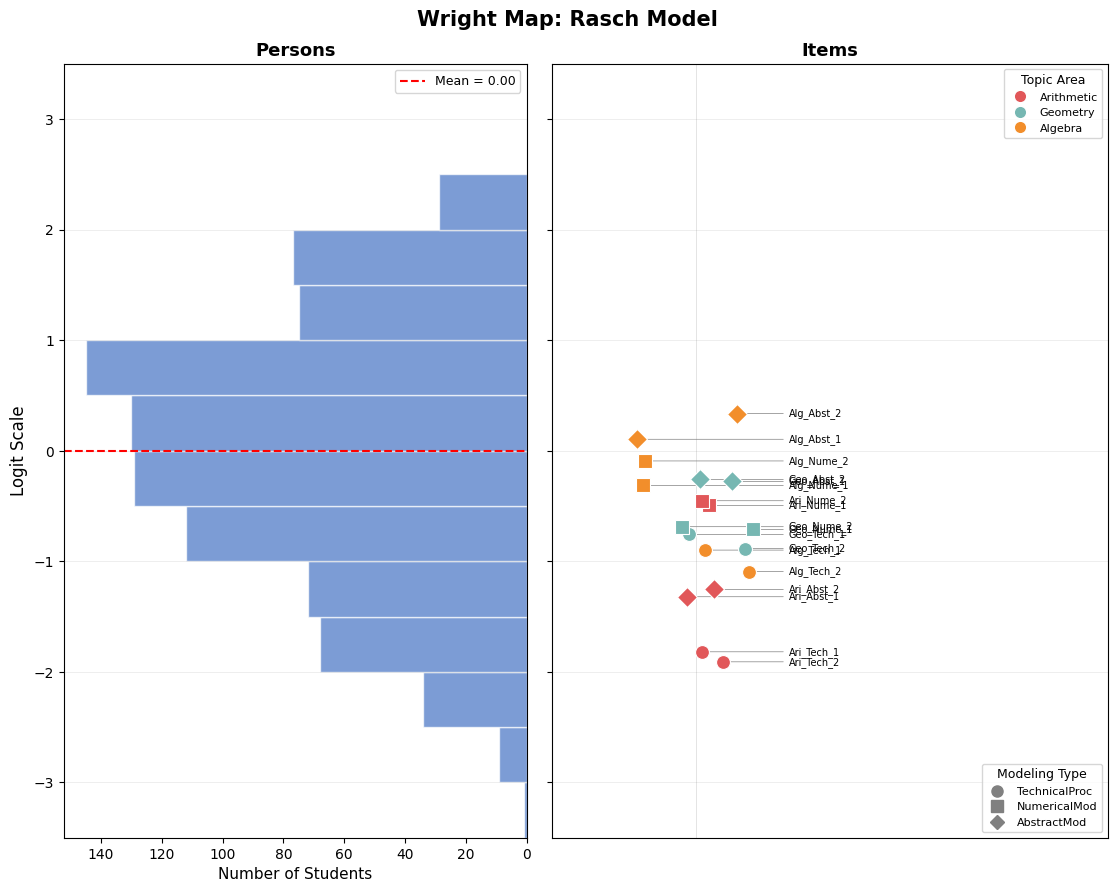

In [7]:
# Rasch model: Wright Map visualization
# Left panel = person ability histogram, Right panel = item difficulty locations

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 9), sharey=True,
                                         gridspec_kw={'width_ratios': [1, 1.2], 'wspace': 0.05})

logit_range = (-3.5, 3.5)

# ── Left panel: person ability distribution ──
theta_bins = np.arange(-4, 4.1, 0.5)
ax_left.hist(theta_eap_rasch, bins=theta_bins, orientation='horizontal',
             color='#4472C4', alpha=0.7, edgecolor='white')
ax_left.set_xlabel('Number of Students', fontsize=11)
ax_left.set_ylabel('Logit Scale', fontsize=12)
ax_left.set_ylim(*logit_range)
ax_left.invert_xaxis()  # histogram grows to the left
ax_left.set_title('Persons', fontsize=13, fontweight='bold')
ax_left.axhline(np.mean(theta_eap_rasch), color='red', linestyle='--', lw=1.5,
                label=f'Mean = {np.mean(theta_eap_rasch):.2f}')
ax_left.legend(fontsize=9)
ax_left.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

# ── Right panel: item difficulty locations ──
colors_topic = {'Arithmetic': '#E15759', 'Geometry': '#76B7B2', 'Algebra': '#F28E2B'}
markers_mt = {'TechnicalProcessing': 'o', 'NumericalModeling': 's', 'AbstractModeling': 'D'}

# Horizontal jitter: spread items that are close in difficulty
np.random.seed(0)
base_x = 0.5
jitter = np.random.uniform(-0.3, 0.3, I)

# Additional repulsion for items that are very close vertically
sorted_idx = np.argsort(beta_est_rasch)
x_positions = np.zeros(I)
for rank, idx in enumerate(sorted_idx):
    x_positions[idx] = base_x + jitter[idx]

for i in range(I):
    row = items_df.iloc[i]
    color = colors_topic[row['topic_area']]
    marker = markers_mt[row['modeling_type']]
    ax_right.plot(x_positions[i], beta_est_rasch[i], marker,
                 color=color, markersize=10, zorder=5,
                 markeredgecolor='white', markeredgewidth=0.8)
    ax_right.annotate(row['item_name'],
                      (x_positions[i], beta_est_rasch[i]),
                      xytext=(0.95, beta_est_rasch[i]),
                      fontsize=7, va='center',
                      arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax_right.set_xlim(-0.2, 2.5)
ax_right.set_ylim(*logit_range)
ax_right.set_title('Items', fontsize=13, fontweight='bold')
ax_right.axvline(base_x, color='gray', linewidth=0.5, linestyle='-', alpha=0.3)
ax_right.set_xticks([])
ax_right.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

# Legend: topic area (color) and modeling type (shape)
from matplotlib.lines import Line2D
legend_color = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E15759', markersize=9, label='Arithmetic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#76B7B2', markersize=9, label='Geometry'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F28E2B', markersize=9, label='Algebra'),
]
legend_shape = [
    Line2D([0], [0], marker='o', color='gray', markersize=8, linestyle='None', label='TechnicalProc'),
    Line2D([0], [0], marker='s', color='gray', markersize=8, linestyle='None', label='NumericalMod'),
    Line2D([0], [0], marker='D', color='gray', markersize=7, linestyle='None', label='AbstractMod'),
]
leg1 = ax_right.legend(handles=legend_color, loc='upper right', title='Topic Area', fontsize=8, title_fontsize=9)
ax_right.add_artist(leg1)
ax_right.legend(handles=legend_shape, loc='lower right', title='Modeling Type', fontsize=8, title_fontsize=9)

fig.suptitle('Wright Map: Rasch Model', fontsize=15, fontweight='bold', y=0.98)
fig.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.06, wspace=0.05)
fig.savefig('fig_wright_map.png', dpi=150, bbox_inches='tight')
print('Figure saved: fig_wright_map.png')
plt.show()

In [8]:
# Save Rasch results
results_rasch = pd.DataFrame({
    "item_name": items_df["item_name"],
    "beta_estimated": np.round(beta_est_rasch, 4),
    "beta_true": np.round(items_df["beta_true"].values, 4),
})
results_rasch.to_csv("results_rasch.csv", index=False)

persons_df_rasch = persons_df.copy()
persons_df_rasch["theta_eap"] = np.round(theta_eap_rasch, 4)
persons_df_rasch.to_csv("results_persons_rasch.csv", index=False)

fit_df_rasch = pd.DataFrame([{
    "model": "Rasch",
    "deviance": round(deviance_rasch, 1),
    "AIC": round(aic_rasch, 1),
    "BIC": round(bic_rasch, 1),
    "n_params": n_params_rasch,
    "person_variance": round(variance_est_rasch, 3),
}])
fit_df_rasch.to_csv("results_fit_rasch.csv", index=False)

print("Rasch results saved.")

Rasch results saved.


### Location Indeterminacy in the Rasch Model

You may notice that the estimated $\hat{\beta}_i$ values are **systematically shifted** from the true $\beta_i$ values — yet their correlation is nearly perfect ($r \approx 0.996$). This is not a bug; it is a fundamental property of the Rasch model called **location indeterminacy**.

The Rasch model specifies $\eta_{pi} = \theta_p - \beta_i$. Only the **differences** $\theta_p - \beta_i$ affect the response probabilities. If we add any constant $c$ to every $\theta_p$ and every $\beta_i$, the likelihood is unchanged:

$$\theta_p - \beta_i = (\theta_p + c) - (\beta_i + c)$$

To make the model identifiable, MML estimation assumes $\theta_p \sim N(0, \sigma^2)$, anchoring the **person mean at zero**. But our simulated data has a true mean ability $\bar{\theta}_{\text{true}} \approx 0.75$ (because most students are in Realschule or Gymnasium with positive program effects). This non-zero mean is absorbed into the item parameters:

$$\hat{\beta}_i \approx \beta_{\text{true},i} - \bar{\theta}_{\text{true}}$$

The cell below demonstrates this shift quantitatively.

Location Indeterminacy in the Rasch Model
  True mean ability (mean theta_true): +0.7529
  Expected shift in beta:              -0.7529
  Observed mean shift (beta_est - beta_true): -0.7665
  SD of shift across items:             0.0519

  Correlation (beta_est vs beta_true):  r = 0.9964
  => Relative ordering is near-perfect; only the origin shifted.


Figure saved: fig_location_indeterminacy_mml.png


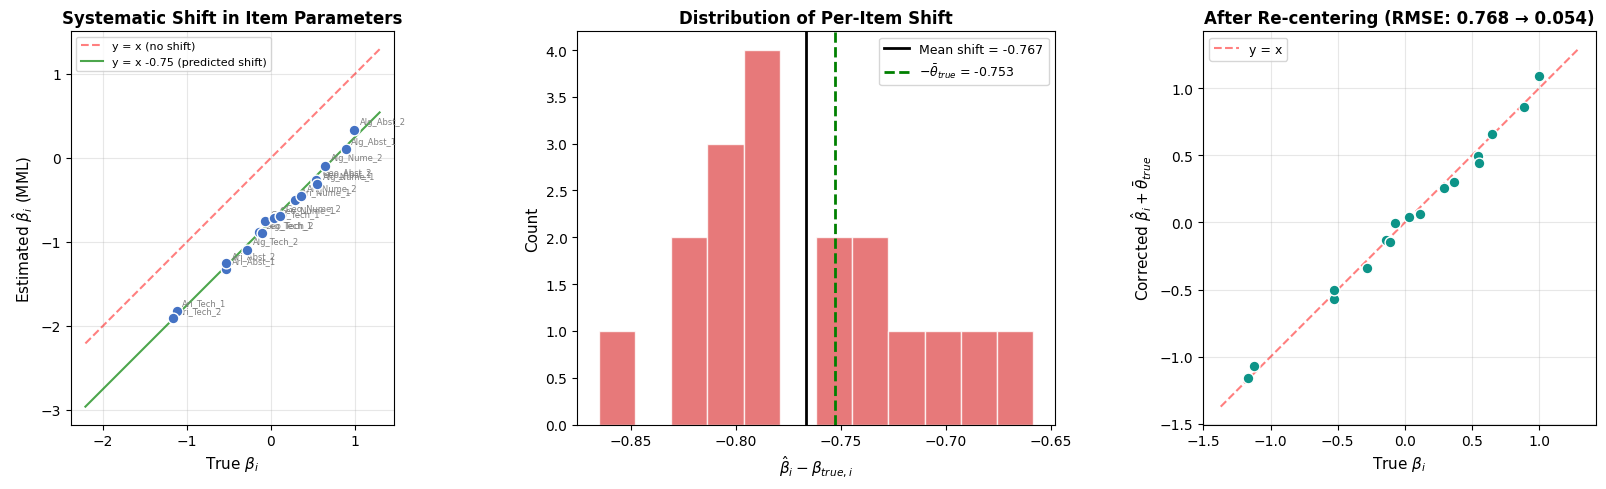


Why do person CIs contain true values but item CIs would not?
  Shift magnitude:       |-0.767| logits
  Typical item SE:       ~0.10 logits  => 95% CI width ~0.40
  Typical person SE:     ~0.53 logits  => 95% CI width ~2.08
  => The shift (0.77) is MUCH larger than item CI width (~0.40)
     but SMALL relative to person CI width (~2.08)
  This is why item true values fall outside CIs but person true values mostly fall inside.


In [9]:
# ── Location Indeterminacy: quantifying the shift ──

true_beta = items_df['beta_true'].values
true_theta = persons_df['theta_true'].values
mu_theta_true = true_theta.mean()

shift = beta_est_rasch - true_beta  # observed shift per item

print('Location Indeterminacy in the Rasch Model')
print('=' * 55)
print(f'  True mean ability (mean theta_true): {mu_theta_true:+.4f}')
print(f'  Expected shift in beta:              {-mu_theta_true:+.4f}')
print(f'  Observed mean shift (beta_est - beta_true): {shift.mean():+.4f}')
print(f'  SD of shift across items:             {shift.std():.4f}')
print()
print(f'  Correlation (beta_est vs beta_true):  r = {np.corrcoef(beta_est_rasch, true_beta)[0,1]:.4f}')
print(f'  => Relative ordering is near-perfect; only the origin shifted.')

# ── Visualization: three panels ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Estimated vs True beta — showing the systematic offset from y=x
ax = axes[0]
ax.scatter(true_beta, beta_est_rasch, c='#4472C4', s=60, edgecolors='white', zorder=5)
lims = [min(true_beta.min(), beta_est_rasch.min()) - 0.3,
        max(true_beta.max(), beta_est_rasch.max()) + 0.3]
ax.plot(lims, lims, 'r--', alpha=0.5, label='y = x (no shift)')
ax.plot(lims, [l - mu_theta_true for l in lims], 'g-', alpha=0.7,
        label=f'y = x {-mu_theta_true:+.2f} (predicted shift)')
for i in range(I):
    ax.annotate(items_df['item_name'].iloc[i], (true_beta[i], beta_est_rasch[i]),
                xytext=(4, 4), textcoords='offset points', fontsize=6, color='gray')
ax.set_xlabel(r'True $\beta_i$', fontsize=11)
ax.set_ylabel(r'Estimated $\hat{\beta}_i$ (MML)', fontsize=11)
ax.set_title('Systematic Shift in Item Parameters', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# (b) Histogram of the per-item shift
ax = axes[1]
ax.hist(shift, bins=12, color='#E15759', edgecolor='white', alpha=0.8)
ax.axvline(shift.mean(), color='black', linestyle='-', lw=2,
           label=f'Mean shift = {shift.mean():.3f}')
ax.axvline(-mu_theta_true, color='green', linestyle='--', lw=2,
           label=f'$-\\bar{{\\theta}}_{{true}}$ = {-mu_theta_true:.3f}')
ax.set_xlabel(r'$\hat{\beta}_i - \beta_{true,i}$', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Per-Item Shift', fontweight='bold')
ax.legend(fontsize=9)

# (c) After correcting the shift: beta_est + mu_theta vs beta_true
ax = axes[2]
beta_corrected = beta_est_rasch + mu_theta_true  # re-center
ax.scatter(true_beta, beta_corrected, c='#0D9488', s=60, edgecolors='white', zorder=5)
lims2 = [min(true_beta.min(), beta_corrected.min()) - 0.2,
         max(true_beta.max(), beta_corrected.max()) + 0.2]
ax.plot(lims2, lims2, 'r--', alpha=0.5, label='y = x')
rmse_before = np.sqrt(np.mean((beta_est_rasch - true_beta)**2))
rmse_after = np.sqrt(np.mean((beta_corrected - true_beta)**2))
ax.set_xlabel(r'True $\beta_i$', fontsize=11)
ax.set_ylabel(r'Corrected $\hat{\beta}_i + \bar{\theta}_{true}$', fontsize=11)
ax.set_title(f'After Re-centering (RMSE: {rmse_before:.3f} \u2192 {rmse_after:.3f})', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
fig.savefig('fig_location_indeterminacy_mml.png', dpi=150, bbox_inches='tight')
print(f'Figure saved: fig_location_indeterminacy_mml.png')
plt.show()

print()
print('Why do person CIs contain true values but item CIs would not?')
print(f'  Shift magnitude:       |{shift.mean():.3f}| logits')
print(f'  Typical item SE:       ~0.10 logits  => 95% CI width ~0.40')
print(f'  Typical person SE:     ~{np.sqrt(theta_var_rasch).mean():.2f} logits  => 95% CI width ~{np.sqrt(theta_var_rasch).mean()*3.92:.2f}')
print(f'  => The shift ({abs(shift.mean()):.2f}) is MUCH larger than item CI width (~0.40)')
print(f'     but SMALL relative to person CI width (~{np.sqrt(theta_var_rasch).mean()*3.92:.2f})')
print(f'  This is why item true values fall outside CIs but person true values mostly fall inside.')

## Part 3: Model 2 — Latent Regression Rasch (Person Explanatory)

$$\eta_{pi} = \sum_j \vartheta_j Z_{pj} + \theta_p - \beta_i$$

In [10]:
# Build person predictor matrix Z
gender = persons_df["gender"].values
program = persons_df["program"].values
hises = persons_df["hises"].values

prog1 = (program == 1).astype(float)
prog3 = (program == 3).astype(float)
prog4 = (program == 4).astype(float)
female = (1 - gender).astype(float)

Z = np.column_stack([prog1, prog3, prog4,
                     female * prog1, female * prog3, female * prog4, hises])
J = Z.shape[1]
predictor_names = ["Program 1 (Hauptschule)", "Program 3 (Realschule)",
                   "Program 4 (Gymnasium)", "Female × Prog 1",
                   "Female × Prog 3", "Female × Prog 4", "SES (HiSES)"]

print(f"Person predictor matrix Z: shape {Z.shape}")
print(f"Predictors: {predictor_names}")

Person predictor matrix Z: shape (881, 7)
Predictors: ['Program 1 (Hauptschule)', 'Program 3 (Realschule)', 'Program 4 (Gymnasium)', 'Female × Prog 1', 'Female × Prog 3', 'Female × Prog 4', 'SES (HiSES)']


In [11]:
# Latent Regression Rasch likelihood
def neg_ll_lat_reg_rasch(params):
    """Negative log likelihood for Latent Regression Rasch model."""
    beta = params[:I]
    theta_coefs = params[I:I+J]
    log_sigma = params[I+J]
    sigma = np.exp(log_sigma)
    theta_fixed = Z @ theta_coefs
    theta_nodes = nodes * sigma * np.sqrt(2)

    log_lik_pq = np.zeros((N, n_quad))
    for q in range(n_quad):
        eta = theta_fixed[:, None] + theta_nodes[q] - beta[None, :]
        lp1 = log_expit(eta)
        lp0 = log_expit(-eta)
        log_lik_pq[:, q] = (resp_matrix * lp1 + (1 - resp_matrix) * lp0).sum(axis=1)

    mx = log_lik_pq.max(axis=1, keepdims=True)
    log_marg = mx.squeeze() + np.log((weights[None, :] * np.exp(log_lik_pq - mx)).sum(axis=1))
    return -log_marg.sum()

# Initial values
p_vals = np.clip(resp_matrix.mean(axis=0), 0.01, 0.99)
beta_init = -np.log(p_vals / (1 - p_vals))
params_init_lat_reg = np.concatenate([beta_init, np.zeros(J), [np.log(0.8)]])

print("Fitting Latent Regression Rasch model...")
best_params_lat_reg, best_nll_lat_reg = minimize_gd(neg_ll_lat_reg_rasch, params_init_lat_reg, maxiter=500, lr=0.015)

beta_est_lat_reg = best_params_lat_reg[:I]
theta_coefs_lat_reg = best_params_lat_reg[I:I+J]
sigma_resid_lat_reg = np.exp(best_params_lat_reg[I+J])
var_resid_lat_reg = sigma_resid_lat_reg ** 2
log_lik_lat_reg = -best_nll_lat_reg

print("Latent Regression Rasch model fitted successfully.")

Fitting Latent Regression Rasch model...


  Iter 0: neg_loglik = 8954.28


  Iter 100: neg_loglik = 8736.85


  Iter 200: neg_loglik = 8735.67


Latent Regression Rasch model fitted successfully.


In [12]:
# Latent Regression Rasch: Results
n_params_lat_reg = I + J + 1
deviance_lat_reg = -2 * log_lik_lat_reg
aic_lat_reg = deviance_lat_reg + 2 * n_params_lat_reg
bic_lat_reg = deviance_lat_reg + np.log(N) * n_params_lat_reg

print("\n" + "="*60)
print("LATENT REGRESSION RASCH MODEL RESULTS")
print("="*60)

print(f"\nPerson Property Effects:")
print(f"{'Predictor':<30} {'Effect':>8}")
print("-" * 40)
for j_idx in range(J):
    print(f"{predictor_names[j_idx]:<30} {theta_coefs_lat_reg[j_idx]:>8.3f}")

print(f"\nResidual person variance (σ²_ε): {var_resid_lat_reg:.3f}")

theta_fixed_all_lat_reg = Z @ theta_coefs_lat_reg
var_fixed_lat_reg = np.var(theta_fixed_all_lat_reg)
var_total_lat_reg = var_fixed_lat_reg + var_resid_lat_reg
pct_lat_reg = var_fixed_lat_reg / var_total_lat_reg * 100

print(f"\nVariance decomposition:")
print(f"  Explained: {var_fixed_lat_reg:.3f}")
print(f"  Residual:  {var_resid_lat_reg:.3f}")
print(f"  Total:     {var_total_lat_reg:.3f}")
print(f"  % expl:    {pct_lat_reg:.1f}%")

print(f"\nFit Indices:")
print(f"  Deviance: {deviance_lat_reg:.1f}")
print(f"  AIC:      {aic_lat_reg:.1f}")
print(f"  BIC:      {bic_lat_reg:.1f}")


LATENT REGRESSION RASCH MODEL RESULTS

Person Property Effects:
Predictor                        Effect
----------------------------------------
Program 1 (Hauptschule)          -0.623
Program 3 (Realschule)            0.688
Program 4 (Gymnasium)             1.724
Female × Prog 1                  -0.053
Female × Prog 3                  -0.192
Female × Prog 4                  -0.225
SES (HiSES)                       0.178

Residual person variance (σ²_ε): 0.675

Variance decomposition:
  Explained: 0.793
  Residual:  0.675
  Total:     1.467
  % expl:    54.0%

Fit Indices:
  Deviance: 17471.1
  AIC:      17523.1
  BIC:      17647.4


In [13]:
# Latent Regression Rasch: Comparison with Rasch Model
print("\nComparison with Rasch Model:")
print(f"  Deviance: {deviance_rasch:.1f} → {deviance_lat_reg:.1f} (Δ = {deviance_lat_reg - deviance_rasch:.1f})")
print(f"  AIC:      {aic_rasch:.1f} → {aic_lat_reg:.1f} (Δ = {aic_lat_reg - aic_rasch:.1f})")
print(f"  BIC:      {bic_rasch:.1f} → {bic_lat_reg:.1f} (Δ = {bic_lat_reg - bic_rasch:.1f})")

# Save results
fit_df_lat_reg = pd.DataFrame([{
    "model": "Latent Regression Rasch",
    "deviance": round(deviance_lat_reg, 1),
    "AIC": round(aic_lat_reg, 1),
    "BIC": round(bic_lat_reg, 1),
    "n_params": n_params_lat_reg,
    "person_variance": round(var_resid_lat_reg, 3)
}])
fit_df_lat_reg.to_csv("results_fit_lat_reg_rasch.csv", index=False)

effects_df = pd.DataFrame({"predictor": predictor_names, "effect": np.round(theta_coefs_lat_reg, 4)})
effects_df.to_csv("results_person_effects.csv", index=False)

print("\nLatent Regression Rasch results saved.")


Comparison with Rasch Model:
  Deviance: 17990.8 → 17471.1 (Δ = -519.7)
  AIC:      18028.8 → 17523.1 (Δ = -505.7)
  BIC:      18119.6 → 17647.4 (Δ = -472.2)

Latent Regression Rasch results saved.


## Part 4: Model 3 — LLTM (Item Explanatory)

$$\eta_{pi} = \theta_p - \sum_k \beta_k X_{ik}$$

In [14]:
# Build item predictor matrix X
topic_areas = ["Arithmetic", "Geometry", "Algebra"]
modeling_types = ["TechnicalProcessing", "NumericalModeling", "AbstractModeling"]

X_item = np.zeros((I, 9))
cell_names = []
for idx, (ta, mt) in enumerate([(ta, mt) for ta in topic_areas for mt in modeling_types]):
    cell_names.append(f"{ta}_{mt}")
    mask = (items_df["topic_area"] == ta) & (items_df["modeling_type"] == mt)
    X_item[mask.values, idx] = 1.0
K = 9

print(f"Item predictor matrix X: shape {X_item.shape}")
print(f"Design cells: {cell_names}")
print(f"Items per cell: {X_item.sum(axis=0).astype(int)}")

Item predictor matrix X: shape (18, 9)
Design cells: ['Arithmetic_TechnicalProcessing', 'Arithmetic_NumericalModeling', 'Arithmetic_AbstractModeling', 'Geometry_TechnicalProcessing', 'Geometry_NumericalModeling', 'Geometry_AbstractModeling', 'Algebra_TechnicalProcessing', 'Algebra_NumericalModeling', 'Algebra_AbstractModeling']
Items per cell: [2 2 2 2 2 2 2 2 2]


In [15]:
# LLTM likelihood
def neg_ll_lltm(params):
    """Negative log likelihood for LLTM model."""
    beta_k = params[:K]
    log_sigma = params[K]
    sigma = np.exp(log_sigma)
    beta_pred = X_item @ beta_k
    theta_nodes = nodes * sigma * np.sqrt(2)
    
    eta = theta_nodes[:, None] - beta_pred[None, :]
    lp1 = log_expit(eta)
    lp0 = log_expit(-eta)
    log_lik_pq = (resp_matrix @ lp1.T) + ((1 - resp_matrix) @ lp0.T)
    
    mx = log_lik_pq.max(axis=1, keepdims=True)
    log_marg = mx.squeeze() + np.log((weights[None, :] * np.exp(log_lik_pq - mx)).sum(axis=1))
    return -log_marg.sum()

# Initial values from cell-specific p-values
p_means = resp_matrix.mean(axis=0)
beta_cell_init = []
for k in range(K):
    mask = X_item[:, k] == 1
    p_cell = np.clip(p_means[mask].mean(), 0.01, 0.99)
    beta_cell_init.append(-np.log(p_cell / (1 - p_cell)))
params_init_lltm = np.array(beta_cell_init + [np.log(1.0)])

print("Fitting LLTM...")
best_params_lltm, best_nll_lltm = minimize_gd(neg_ll_lltm, params_init_lltm, maxiter=400, lr=0.02)

beta_k_est_lltm = best_params_lltm[:K]
sigma_est_lltm = np.exp(best_params_lltm[K])
variance_est_lltm = sigma_est_lltm ** 2
log_lik_lltm = -best_nll_lltm
beta_pred_lltm = X_item @ beta_k_est_lltm

print("LLTM fitted successfully.")

Fitting LLTM...
  Iter 0: neg_loglik = 9036.96
LLTM fitted successfully.


In [16]:
# LLTM: Results
n_params_lltm = K + 1
deviance_lltm = -2 * log_lik_lltm
aic_lltm = deviance_lltm + 2 * n_params_lltm
bic_lltm = deviance_lltm + np.log(N) * n_params_lltm

print("\n" + "="*60)
print("LLTM RESULTS")
print("="*60)

print(f"\nItem Property Effects (β_k):")
print(f"{'Topic Area':<15} {'Modeling Type':<25} {'Effect':>8}")
print("-" * 50)
for k in range(K):
    parts = cell_names[k].split("_", 1)
    print(f"{parts[0]:<15} {parts[1]:<25} {beta_k_est_lltm[k]:>8.3f}")

print(f"\nPerson variance: {variance_est_lltm:.3f}")
print(f"\nFit Indices:")
print(f"  Deviance: {deviance_lltm:.1f}")
print(f"  AIC:      {aic_lltm:.1f}")
print(f"  BIC:      {bic_lltm:.1f}")


LLTM RESULTS

Item Property Effects (β_k):
Topic Area      Modeling Type               Effect
--------------------------------------------------
Arithmetic      TechnicalProcessing         -1.864
Arithmetic      NumericalModeling           -0.475
Arithmetic      AbstractModeling            -1.288
Geometry        TechnicalProcessing         -0.822
Geometry        NumericalModeling           -0.701
Geometry        AbstractModeling            -0.269
Algebra         TechnicalProcessing         -0.996
Algebra         NumericalModeling           -0.204
Algebra         AbstractModeling             0.218

Person variance: 1.531

Fit Indices:
  Deviance: 18004.5
  AIC:      18024.5
  BIC:      18072.3



Correlation (LLTM pred vs Rasch est): r = 0.993


Figure saved: fig_rasch_vs_lltm.png


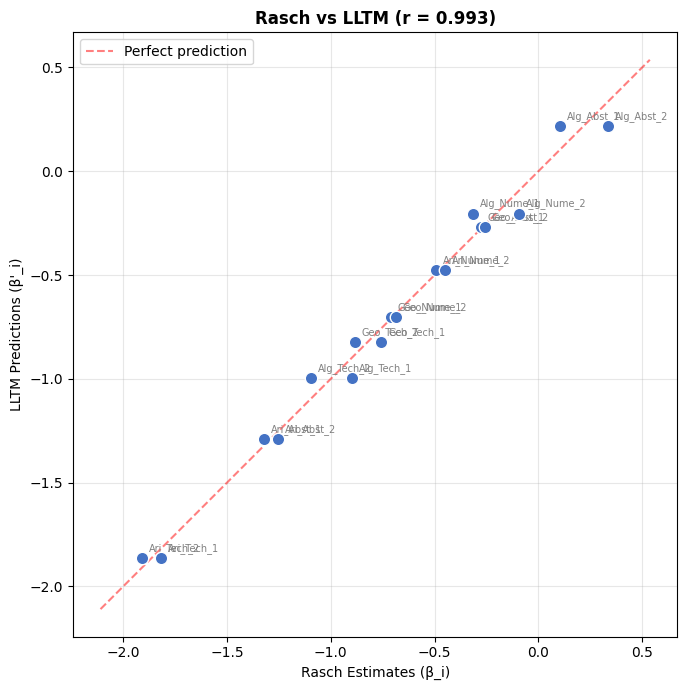

In [17]:
# LLTM: Rasch vs LLTM scatter plot
r_lltm = np.corrcoef(beta_pred_lltm, beta_est_rasch)[0, 1]
print(f"\nCorrelation (LLTM pred vs Rasch est): r = {r_lltm:.3f}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(beta_est_rasch, beta_pred_lltm, c="#4472C4", s=80, zorder=5, edgecolors="white")
for i in range(I):
    ax.annotate(items_df["item_name"].iloc[i], (beta_est_rasch[i], beta_pred_lltm[i]),
                xytext=(5, 5), textcoords="offset points", fontsize=7, color="gray")
lims = [min(beta_est_rasch.min(), beta_pred_lltm.min()) - 0.2,
        max(beta_est_rasch.max(), beta_pred_lltm.max()) + 0.2]
ax.plot(lims, lims, "r--", alpha=0.5, label="Perfect prediction")
ax.set_xlabel("Rasch Estimates (β_i)")
ax.set_ylabel("LLTM Predictions (β'_i)")
ax.set_title(f"Rasch vs LLTM (r = {r_lltm:.3f})", fontweight="bold")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("fig_rasch_vs_lltm.png", dpi=150, bbox_inches="tight")
print("Figure saved: fig_rasch_vs_lltm.png")
plt.show()

In [18]:
# Save LLTM results
fit_df_lltm = pd.DataFrame([{
    "model": "LLTM",
    "deviance": round(deviance_lltm, 1),
    "AIC": round(aic_lltm, 1),
    "BIC": round(bic_lltm, 1),
    "n_params": n_params_lltm,
    "person_variance": round(variance_est_lltm, 3)
}])
fit_df_lltm.to_csv("results_fit_lltm.csv", index=False)

lltm_effects = pd.DataFrame({"cell": cell_names, "beta_k": np.round(beta_k_est_lltm, 4)})
lltm_effects.to_csv("results_lltm_effects.csv", index=False)

print("LLTM results saved.")

LLTM results saved.


## Part 5: Model 4 — Latent Regression LLTM (Doubly Explanatory)

$$\eta_{pi} = \sum_j \vartheta_j Z_{pj} + \theta_p - \sum_k \beta_k X_{ik}$$

In [19]:
# Latent Regression LLTM likelihood
def neg_ll_lat_reg_lltm(params):
    """Negative log likelihood for Latent Regression LLTM model."""
    beta_k = params[:K]
    theta_coefs = params[K:K+J]
    log_sigma = params[K+J]
    sigma = np.exp(log_sigma)
    beta_pred = X_item @ beta_k
    theta_fixed = Z @ theta_coefs
    theta_nodes = nodes * sigma * np.sqrt(2)

    log_lik_pq = np.zeros((N, n_quad))
    for q in range(n_quad):
        eta = theta_fixed[:, None] + theta_nodes[q] - beta_pred[None, :]
        lp1 = log_expit(eta)
        lp0 = log_expit(-eta)
        log_lik_pq[:, q] = (resp_matrix * lp1 + (1 - resp_matrix) * lp0).sum(axis=1)

    mx = log_lik_pq.max(axis=1, keepdims=True)
    log_marg = mx.squeeze() + np.log((weights[None, :] * np.exp(log_lik_pq - mx)).sum(axis=1))
    return -log_marg.sum()

# Initial values
p_means = resp_matrix.mean(axis=0)
beta_cell_init = []
for k in range(K):
    mask = X_item[:, k] == 1
    p_cell = np.clip(p_means[mask].mean(), 0.01, 0.99)
    beta_cell_init.append(-np.log(p_cell / (1 - p_cell)))
params_init_lat_reg_lltm = np.array(beta_cell_init + [0.0]*J + [np.log(0.8)])

print("Fitting Latent Regression LLTM (doubly explanatory)...")
best_params_lat_reg_lltm, best_nll_lat_reg_lltm = minimize_gd(neg_ll_lat_reg_lltm, params_init_lat_reg_lltm, maxiter=600, lr=0.012)

beta_k_est_lat_reg_lltm = best_params_lat_reg_lltm[:K]
theta_coefs_lat_reg_lltm = best_params_lat_reg_lltm[K:K+J]
sigma_resid_lat_reg_lltm = np.exp(best_params_lat_reg_lltm[K+J])
var_resid_lat_reg_lltm = sigma_resid_lat_reg_lltm ** 2
log_lik_lat_reg_lltm = -best_nll_lat_reg_lltm

print("Latent Regression LLTM fitted successfully.")

Fitting Latent Regression LLTM (doubly explanatory)...


  Iter 0: neg_loglik = 8916.38


  Iter 100: neg_loglik = 8742.50


Latent Regression LLTM fitted successfully.


In [20]:
# Latent Regression LLTM: Results
n_params_lat_reg_lltm = K + J + 1
deviance_lat_reg_lltm = -2 * log_lik_lat_reg_lltm
aic_lat_reg_lltm = deviance_lat_reg_lltm + 2 * n_params_lat_reg_lltm
bic_lat_reg_lltm = deviance_lat_reg_lltm + np.log(N) * n_params_lat_reg_lltm

print("\n" + "="*60)
print("LATENT REGRESSION LLTM (DOUBLY EXPLANATORY)")
print("="*60)

print(f"\nItem Property Effects:")
for k in range(K):
    print(f"  {cell_names[k]:<35} {beta_k_est_lat_reg_lltm[k]:>8.3f}")

person_pred_names = ["Program 1", "Program 3", "Program 4",
                     "Female×Prog1", "Female×Prog3", "Female×Prog4", "SES"]

print(f"\nPerson Property Effects:")
for j_idx in range(J):
    print(f"  {person_pred_names[j_idx]:<25} {theta_coefs_lat_reg_lltm[j_idx]:>8.3f}")

theta_fixed_all_lat_reg_lltm = Z @ theta_coefs_lat_reg_lltm
var_fixed_lat_reg_lltm = np.var(theta_fixed_all_lat_reg_lltm)
var_total_lat_reg_lltm = var_fixed_lat_reg_lltm + var_resid_lat_reg_lltm

print(f"\nVariance: Explained={var_fixed_lat_reg_lltm:.3f}, Residual={var_resid_lat_reg_lltm:.3f}, Total={var_total_lat_reg_lltm:.3f}")
print(f"% explained: {var_fixed_lat_reg_lltm/var_total_lat_reg_lltm*100:.1f}%")
print(f"\nFit: Deviance={deviance_lat_reg_lltm:.1f}, AIC={aic_lat_reg_lltm:.1f}, BIC={bic_lat_reg_lltm:.1f}")


LATENT REGRESSION LLTM (DOUBLY EXPLANATORY)

Item Property Effects:
  Arithmetic_TechnicalProcessing        -1.199
  Arithmetic_NumericalModeling           0.192
  Arithmetic_AbstractModeling           -0.623
  Geometry_TechnicalProcessing          -0.156
  Geometry_NumericalModeling            -0.035
  Geometry_AbstractModeling              0.397
  Algebra_TechnicalProcessing           -0.330
  Algebra_NumericalModeling              0.463
  Algebra_AbstractModeling               0.884

Person Property Effects:
  Program 1                   -0.610
  Program 3                    0.700
  Program 4                    1.735
  Female×Prog1                -0.053
  Female×Prog3                -0.192
  Female×Prog4                -0.225
  SES                          0.177

Variance: Explained=0.792, Residual=0.673, Total=1.465
% explained: 54.1%

Fit: Deviance=17484.8, AIC=17518.8, BIC=17600.0


In [21]:
# Model comparison
print("\n" + "="*60)
print("MODEL COMPARISON (Table 5 from the chapter)")
print("="*60)

comparison_data = [
    {"model": "Rasch", "deviance": round(deviance_rasch, 1), "AIC": round(aic_rasch, 1), "BIC": round(bic_rasch, 1), "n_params": n_params_rasch, "person_variance": round(variance_est_rasch, 3)},
    {"model": "Latent Regression Rasch", "deviance": round(deviance_lat_reg, 1), "AIC": round(aic_lat_reg, 1), "BIC": round(bic_lat_reg, 1), "n_params": n_params_lat_reg, "person_variance": round(var_resid_lat_reg, 3)},
    {"model": "LLTM", "deviance": round(deviance_lltm, 1), "AIC": round(aic_lltm, 1), "BIC": round(bic_lltm, 1), "n_params": n_params_lltm, "person_variance": round(variance_est_lltm, 3)},
    {"model": "Latent Regression LLTM", "deviance": round(deviance_lat_reg_lltm, 1), "AIC": round(aic_lat_reg_lltm, 1), "BIC": round(bic_lat_reg_lltm, 1), "n_params": n_params_lat_reg_lltm, "person_variance": round(var_resid_lat_reg_lltm, 3)},
]

comparison_df = pd.DataFrame(comparison_data)
print(f"\n{'Model':<30} {'Deviance':>10} {'AIC':>10} {'BIC':>10} {'#Params':>8}")
print("-" * 70)
for _, row in comparison_df.iterrows():
    print(f"{row['model']:<30} {row['deviance']:>10.1f} {row['AIC']:>10.1f} {row['BIC']:>10.1f} {int(row['n_params']):>8}")

comparison_df.to_csv("results_model_comparison.csv", index=False)
print("\nComparison table saved to results_model_comparison.csv")


MODEL COMPARISON (Table 5 from the chapter)

Model                            Deviance        AIC        BIC  #Params
----------------------------------------------------------------------
Rasch                             17990.8    18028.8    18119.6       19
Latent Regression Rasch           17471.1    17523.1    17647.4       26
LLTM                              18004.5    18024.5    18072.3       10
Latent Regression LLTM            17484.8    17518.8    17600.0       17

Comparison table saved to results_model_comparison.csv


Figure saved: fig_model_comparison.png


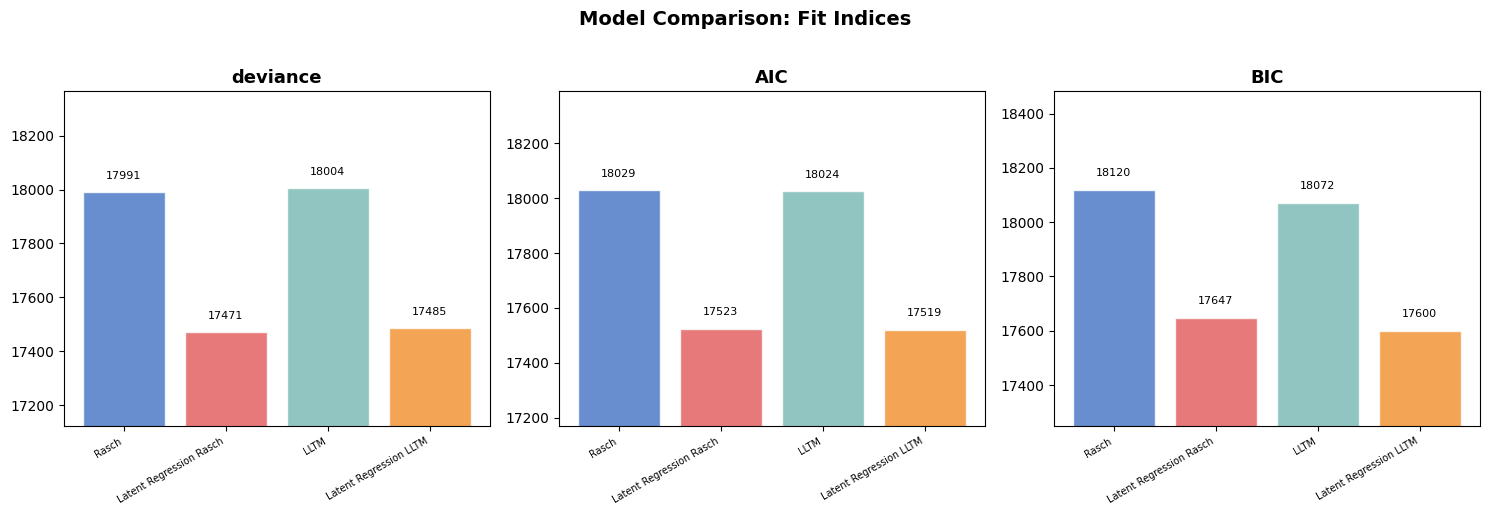

In [22]:
# Model comparison visualization: Fit indices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = comparison_df["model"].tolist()
x = np.arange(len(models))
for ax, metric in zip(axes, ["deviance", "AIC", "BIC"]):
    values = comparison_df[metric].values
    colors = ["#4472C4", "#E15759", "#76B7B2", "#F28E2B"]
    bars = ax.bar(x, values, color=colors, alpha=0.8, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=7)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f"{val:.0f}", ha="center", fontsize=8)
    ax.set_ylim(min(values)*0.98, max(values)*1.02)

plt.suptitle("Model Comparison: Fit Indices", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("fig_model_comparison.png", dpi=150, bbox_inches="tight")
print("Figure saved: fig_model_comparison.png")
plt.show()

Figure saved: fig_icc_curves.png


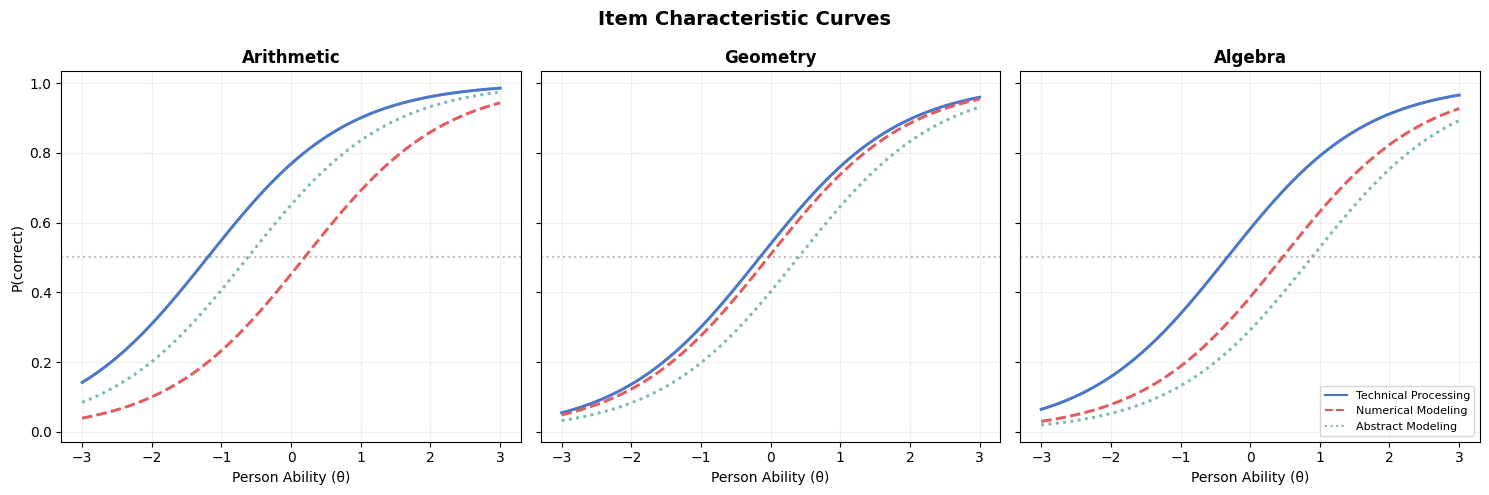

In [23]:
# ICC curves by topic area
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
beta_pred_lat_reg_lltm = X_item @ beta_k_est_lat_reg_lltm
theta_range = np.linspace(-3, 3, 100)

for ax_idx, ta in enumerate(topic_areas):
    ax = axes[ax_idx]
    ta_mask = items_df["topic_area"] == ta
    
    for i in range(I):
        if not ta_mask.iloc[i]:
            continue
        p_curve = expit(theta_range - beta_pred_lat_reg_lltm[i])
        mt = items_df["modeling_type"].iloc[i]
        style = {"TechnicalProcessing": "-", "NumericalModeling": "--", "AbstractModeling": ":"}[mt]
        color = {"TechnicalProcessing": "#4472C4", "NumericalModeling": "#E15759",
                 "AbstractModeling": "#76B7B2"}[mt]
        ax.plot(theta_range, p_curve, style, color=color, linewidth=2, alpha=0.8)
    
    ax.set_xlabel("Person Ability (θ)")
    ax.set_title(ta, fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("P(correct)")

legend_elements = [
    Line2D([0], [0], color="#4472C4", linestyle="-", label="Technical Processing"),
    Line2D([0], [0], color="#E15759", linestyle="--", label="Numerical Modeling"),
    Line2D([0], [0], color="#76B7B2", linestyle=":", label="Abstract Modeling")
]
axes[2].legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.suptitle("Item Characteristic Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig("fig_icc_curves.png", dpi=150, bbox_inches="tight")
print("Figure saved: fig_icc_curves.png")
plt.show()

In [24]:
# Save final model results
fit_df_lat_reg_lltm = pd.DataFrame([{
    "model": "Latent Regression LLTM",
    "deviance": round(deviance_lat_reg_lltm, 1),
    "AIC": round(aic_lat_reg_lltm, 1),
    "BIC": round(bic_lat_reg_lltm, 1),
    "n_params": n_params_lat_reg_lltm,
    "person_variance": round(var_resid_lat_reg_lltm, 3)
}])
fit_df_lat_reg_lltm.to_csv("results_fit_lat_reg_lltm.csv", index=False)

print("All model results saved.")

All model results saved.


## Summary

All four models have been fit successfully. Key findings:

- **Model 1 (Rasch)**: The baseline doubly descriptive model. Estimates item difficulties and person variance.

- **Model 2 (Latent Regression Rasch)**: Adds person predictors (program, gender, SES). Reduces the residual person variance by explaining part of it through observed characteristics.

- **Model 3 (LLTM)**: Constrains item parameters to follow a 3×3 design (3 topic areas × 3 modeling types). Much fewer item parameters than Rasch.

- **Model 4 (Latent Regression LLTM)**: Combines both person and item explanatory structure. The most constrained and potentially most parsimonious model.

Use BIC to compare model fit — it balances likelihood with parsimony. The Wright Map and ICC curves show how students and items align on the latent ability scale.